In [1]:
import os
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import (train_test_split, KFold, StratifiedKFold, cross_val_score)
from sklearn.metrics import classification_report
import warnings
warnings.filterwarnings('ignore')
sns.set_style('darkgrid')

#for dirname, _, filenames in os.walk('/kaggle/input'):
#    for filename in filenames:
#        print(os.path.join(dirname, filename))


In [2]:
data = load_wine()
X, y = data.data, data.target
feature_names = data.feature_names
class_names   = data.target_names

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
print(f"Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")

Train size: 133 | Test size: 45


In [4]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [5]:
y_pred = dt.predict(X_test)
print("\n── Classification Report (Holdout) ──")
print(classification_report(y_test, y_pred, target_names=class_names))


── Classification Report (Holdout) ──
              precision    recall  f1-score   support

     class_0       1.00      0.93      0.97        15
     class_1       0.90      1.00      0.95        18
     class_2       1.00      0.92      0.96        12

    accuracy                           0.96        45
   macro avg       0.97      0.95      0.96        45
weighted avg       0.96      0.96      0.96        45



In [6]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
kf_scores = cross_val_score(DecisionTreeClassifier(random_state=42), X, y, cv=kf, scoring='accuracy')

In [7]:
print("\n── K-Fold Cross-Validation (k=5) ──")
for i, score in enumerate(kf_scores, 1):
    print(f"  Fold {i}: {score:.4f}")
print(f"  Mean : {kf_scores.mean():.4f}")
print(f"  Std  : {kf_scores.std():.4f}")


── K-Fold Cross-Validation (k=5) ──
  Fold 1: 0.9444
  Fold 2: 0.8056
  Fold 3: 0.8889
  Fold 4: 0.8857
  Fold 5: 0.8571
  Mean : 0.8763
  Std  : 0.0453


In [8]:
skf       = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
skf_scores = cross_val_score(DecisionTreeClassifier(random_state=42),
                              X, y, cv=skf, scoring='accuracy')

print("\n── Stratified K-Fold Cross-Validation (k=5) ──")
for i, score in enumerate(skf_scores, 1):
    print(f"  Fold {i}: {score:.4f}")
print(f"  Mean : {skf_scores.mean():.4f}")
print(f"  Std  : {skf_scores.std():.4f}")


── Stratified K-Fold Cross-Validation (k=5) ──
  Fold 1: 0.8889
  Fold 2: 0.9167
  Fold 3: 0.8889
  Fold 4: 0.8286
  Fold 5: 0.9429
  Mean : 0.8932
  Std  : 0.0380


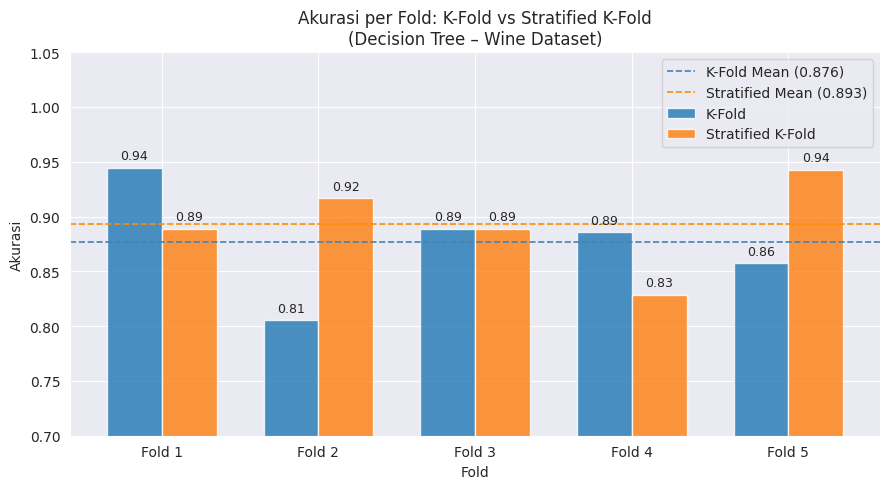

In [9]:
folds   = np.arange(1, 6)
width   = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(folds - width/2, kf_scores,  width, label='K-Fold',            alpha=0.8)
bars2 = ax.bar(folds + width/2, skf_scores, width, label='Stratified K-Fold', alpha=0.8)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)

ax.axhline(kf_scores.mean(),  color='steelblue', linestyle='--',
           linewidth=1.2, label=f'K-Fold Mean ({kf_scores.mean():.3f})')
ax.axhline(skf_scores.mean(), color='darkorange', linestyle='--',
           linewidth=1.2, label=f'Stratified Mean ({skf_scores.mean():.3f})')

ax.set_xlabel('Fold')
ax.set_ylabel('Akurasi')
ax.set_title('Akurasi per Fold: K-Fold vs Stratified K-Fold\n(Decision Tree – Wine Dataset)')
ax.set_xticks(folds)
ax.set_xticklabels([f'Fold {i}' for i in folds])
ax.set_ylim(0.7, 1.05)
ax.legend()
plt.tight_layout()
plt.show()

In [10]:
comparison = pd.DataFrame({
    'Method'   : ['K-Fold (k=5)', 'Stratified K-Fold (k=5)'],
    'Mean Acc' : [kf_scores.mean(),  skf_scores.mean()],
    'Std Dev'  : [kf_scores.std(),   skf_scores.std()],
    'Min Fold' : [kf_scores.min(),   skf_scores.min()],
    'Max Fold' : [kf_scores.max(),   skf_scores.max()],
})
comparison[['Mean Acc','Std Dev','Min Fold','Max Fold']] = \
    comparison[['Mean Acc','Std Dev','Min Fold','Max Fold']].round(4)

print("\n── Tabel Perbandingan ──")
print(comparison.to_string(index=False))


── Tabel Perbandingan ──
                 Method  Mean Acc  Std Dev  Min Fold  Max Fold
           K-Fold (k=5)    0.8763   0.0453    0.8056    0.9444
Stratified K-Fold (k=5)    0.8932   0.0380    0.8286    0.9429


## Analisis Cross-Validation

---

### 1. Perbedaan K-Fold vs Stratified K-Fold

#### K-Fold Cross-Validation
K-Fold membagi dataset menjadi **k bagian (fold) secara acak** tanpa memperhatikan
proporsi kelas di setiap fold. Akibatnya, bisa saja satu fold didominasi oleh satu kelas
tertentu, sehingga evaluasi menjadi kurang representatif.

#### Stratified K-Fold Cross-Validation
Stratified K-Fold membagi dataset dengan memastikan **proporsi setiap kelas tetap
terjaga di setiap fold**, sesuai dengan proporsi kelas pada dataset asli.

| Aspek | K-Fold | Stratified K-Fold |
|---|---|---|
| Pembagian data | Acak tanpa memperhatikan kelas | Menjaga proporsi kelas di tiap fold |
| Representasi kelas | Bisa tidak merata | Selalu merata di setiap fold |
| Cocok untuk | Data dengan kelas seimbang | Data dengan kelas **tidak seimbang** |
| Hasil evaluasi | Bisa bervariasi antar fold | Lebih stabil dan konsisten |
| Std deviasi | Cenderung lebih tinggi | Cenderung lebih rendah |

#### Kapan Sebaiknya Stratified K-Fold Digunakan?
Stratified K-Fold **sangat direkomendasikan** dalam kondisi berikut:

- **Dataset imbalanced** → ketika satu kelas jauh lebih banyak dari kelas lain
  (contoh: 90% kelas A, 10% kelas B)
- **Dataset kecil** → agar setiap fold tetap memiliki sampel yang representatif
  dari semua kelas
- **Klasifikasi multi-kelas** → seperti dataset Iris (3 kelas) atau Wine (3 kelas),
  di mana penting memastikan setiap kelas terwakili di tiap fold
- **Ketika akurasi antar fold sangat bervariasi** → Stratified K-Fold membantu
  menstabilkan hasil evaluasi

> Pada dataset Wine yang digunakan dalam eksperimen ini, Stratified K-Fold
> menghasilkan **standar deviasi yang lebih rendah**, membuktikan bahwa evaluasinya
> lebih konsisten dibanding K-Fold biasa.

---

### 2. Mengapa Cross-Validation Lebih Diandalkan Dibanding Simple Holdout?

#### Kelemahan Simple Holdout
Pada simple holdout, dataset hanya dibagi **satu kali** menjadi training dan test set.
Ini berarti:
- Hasil evaluasi **sangat bergantung pada bagaimana data kebetulan terbagi**
- Jika test set secara kebetulan berisi data yang "mudah" atau "sulit", hasil akurasi
  menjadi **tidak representatif**
- Model hanya dilatih dan diuji **satu kali**, sehingga hasilnya tidak stabil

#### Keunggulan Cross-Validation

| Aspek | Simple Holdout | Cross-Validation |
|---|---|---|
| Jumlah evaluasi | 1 kali | k kali (misal 5 kali) |
| Penggunaan data | Sebagian data tidak dilatih | **Semua data** digunakan untuk training & testing |
| Stabilitas hasil | Bergantung pada random split | Lebih stabil karena dirata-rata dari k fold |
| Deteksi overfitting | Kurang akurat | Lebih akurat |
| Cocok untuk dataset kecil | Kurang | Sangat cocok |

#### Kesimpulan
Cross-validation lebih diandalkan karena:

1. **Semua data digunakan** untuk training dan testing secara bergantian,
   sehingga tidak ada data yang "terbuang"
2. **Hasil lebih stabil** karena akurasi akhir merupakan rata-rata dari k fold,
   bukan hanya satu percobaan
3. **Estimasi performa lebih realistis** terhadap data baru yang belum pernah dilihat model
4. **Variance lebih rendah** — standar deviasi antar fold menunjukkan seberapa
   konsisten model bekerja di berbagai subset data

> Semakin kecil standar deviasi antar fold, semakin **stabil dan dapat diandalkan**
> model tersebut untuk digunakan pada data nyata.